# Astronomy Application

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import sys

sys.path.append('/Users/leonardosantoro/Documents/GitHub/RiemannianEB/src')
from utils import *

In [2]:
plt.rcParams.update({'font.size': 10,
                     'mathtext.fontset': 'stix',
                     'font.family': 'serif',
                     'font.serif':'Palatino'})
sphere = Hypersphere(dim=2)

# Function to plot spherical coordinates (theta, phi) to Mollweide lon/lat projection
def scatter_mollwide(X, ax, color, alpha=.5, s=5, lw=.5):
    X_sph = sphere.extrinsic_to_spherical(X)
    theta = X_sph[:, 0]  # colatitude
    phi = X_sph[:, 1]    # longitude

    # Convert to Mollweide coordinates
    phi_mw = phi - np.pi           # shift longitude from [0, 2π] to [-π, π]
    theta_mw = np.pi/2 - theta     # convert colatitude to latitude [-π/2, π/2]

    # Plot with color parameter
    ax.scatter(phi_mw, theta_mw, s=s, alpha=alpha, color=color)
    ax.grid(True, color='gray', lw=lw)
    return None

## Setting up

In [ ]:
df = pd.read_csv('data/BATSE_4B.txt', header=None, sep='\s+', encoding='utf-8')

# Assume column 5 = RA, column 6 = Dec (in degrees)
ra = df[5].values
dec = df[6].values
phi = np.deg2rad(ra)           # longitude
theta = np.pi/2 - np.deg2rad(dec)  # colatitude
sphere = Hypersphere(dim=2)
X_sph = np.column_stack([theta, phi])
X = sphere.spherical_to_extrinsic(X_sph)

In [7]:
sigma2 = np.mean(np.power(df[9].values * np.pi/180.,2))
sigma2

0.009240724037789944

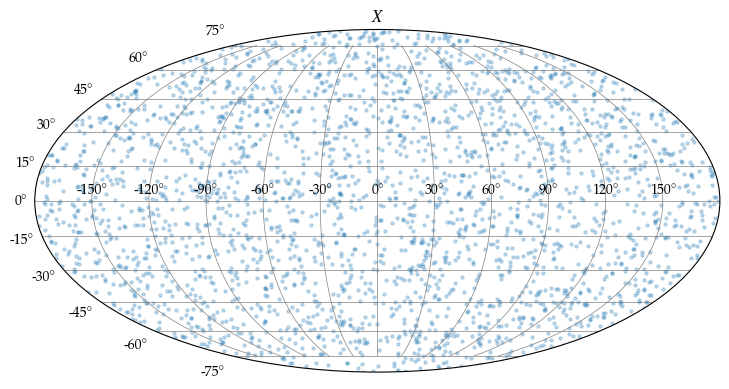

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4), subplot_kw={'projection': 'mollweide'})
#  plot: X
scatter_mollwide(X, ax, color='C0', alpha=0.25)  # Changed axs[0] to axs[1]
ax.set_title('$X$')
plt.tight_layout()
plt.show()

## Density estimation

In [32]:
# Grid on S^2 (theta = colatitude, phi = longitude)
res_lat = 25
res_lon = 25
grid_theta, grid_phi = np.meshgrid(
    np.linspace(0, np.pi, res_lat),        # colatitude
    np.linspace(0, 2*np.pi, res_lon)      # longitude
)
X_grid = np.stack([
    np.sin(grid_theta) * np.cos(grid_phi),
    np.sin(grid_theta) * np.sin(grid_phi),
    np.cos(grid_theta)
], axis=-1).reshape(-1,3)


M = 7
rho = 1e-4
X_grid, hat_f, hat_grad_f = density_estimate('S2', X, M, X_grid)


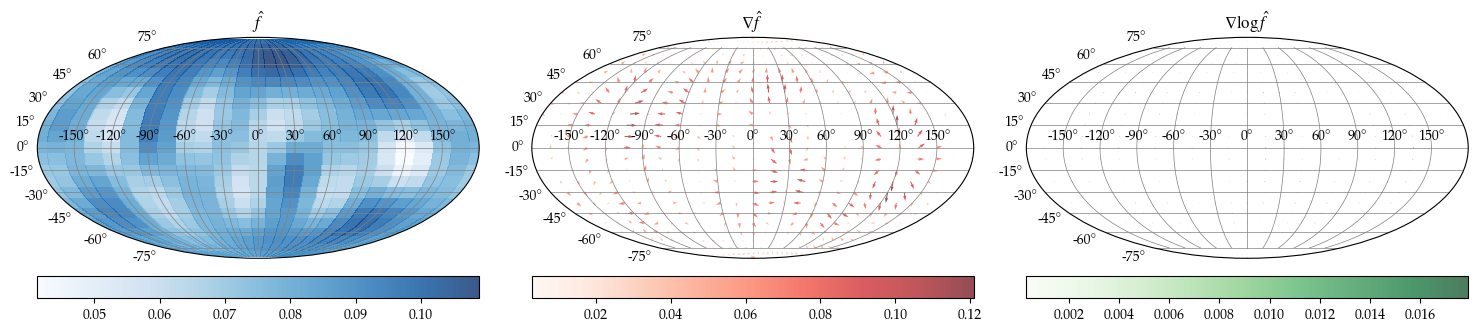

In [33]:
# Grid on S^2 (theta = colatitude, phi = longitude)
res_lat = 25
res_lon = 25
grid_theta, grid_phi = np.meshgrid(
    np.linspace(0, np.pi, res_lat),        # colatitude
    np.linspace(0, 2*np.pi, res_lon)      # longitude
)
X_grid = np.stack([
    np.sin(grid_theta) * np.cos(grid_phi),
    np.sin(grid_theta) * np.sin(grid_phi),
    np.cos(grid_theta)
], axis=-1).reshape(-1,3)

X_grid, hat_f, hat_grad_f = density_estimate('S2', X, M, X_grid)
hat_score = sigma2*  hat_grad_f / np.maximum(hat_f[:, np.newaxis], rho)
# -------------------------------------------------- PLOTTING -------------------------------------------------- #
fig, axs = plt.subplots( 1, 3,figsize=(15, 5), subplot_kw={'projection': 'mollweide'})
grid_phi_mw = (grid_phi - np.pi)          # longitude in [-pi, pi]
grid_theta_mw = (np.pi/2 - grid_theta)    # latitude in [-pi/2, pi/2]
# Plot estimated density --------------------------------------------------
axs[0].grid(True, color='gray', lw=0.5)
axs[0].set_title(r'$\hat f$')
im_f = axs[0].pcolormesh(grid_phi_mw, grid_theta_mw, 
                         hat_f.reshape(res_lat, res_lon),
                         alpha=0.8,shading='auto',cmap='Blues')
fig.colorbar(im_f, ax=axs[0], orientation='horizontal', fraction=0.05, pad=0.04)
# Plot gradient --------------------------------------------------
axs[1].grid(True, color='gray', lw=0.5)
axs[1].set_title(r'$\nabla \hat f$')
hat_grad_f_reshaped = hat_grad_f.reshape(res_lat, res_lon, 3)
e_theta = np.stack([ 
    np.cos(grid_theta) * np.cos(grid_phi), np.cos(grid_theta) * np.sin(grid_phi), -np.sin(grid_theta)
                ], axis=-1)
e_phi = np.stack([
     -np.sin(grid_phi), np.cos(grid_phi), np.zeros_like(grid_phi)
                    ], axis=-1)
grad_theta = -np.sum(hat_grad_f_reshaped * e_theta, axis=-1) # Project gradient onto tangent directions
grad_phi = np.sum(hat_grad_f_reshaped * e_phi, axis=-1)
skip = 1  # Subsample for clearer visualization
im_grad = axs[1].quiver(grid_phi_mw[::skip, ::skip], grid_theta_mw[::skip, ::skip],
              grad_phi[::skip, ::skip], grad_theta[::skip, ::skip],
              np.sqrt(grad_theta**2 + grad_phi**2)[::skip, ::skip],
              scale= 5, cmap='Reds', alpha=0.7)

fig.colorbar(im_grad, ax=axs[1], orientation='horizontal', fraction=0.05, pad=0.04)
# Plot score --------------------------------------------------
hat_score_reshaped = hat_score.reshape(res_lat, res_lon, 3)
grad_theta_score = -np.sum(hat_score_reshaped * e_theta, axis=-1) # Project score onto tangent directions
grad_phi_score = np.sum(hat_score_reshaped * e_phi, axis=-1)

axs[2].grid(True, color='gray', lw=0.5)
axs[2].set_title(r'$\nabla \log \hat f$')

skip = 1  # Subsample for clearer visualization
im_score = axs[2].quiver(grid_phi_mw[::skip, ::skip], grid_theta_mw[::skip, ::skip],
              grad_phi_score[::skip, ::skip], grad_theta_score[::skip, ::skip],
              np.sqrt(grad_theta_score**2 + grad_phi_score**2)[::skip, ::skip],
              scale= 5, cmap='Greens', alpha=0.7)
fig.colorbar(im_score, ax=axs[2], orientation='horizontal', fraction=0.05, pad=0.04)
plt.tight_layout()
plt.show()

## Empirical Bayes denoising

In [34]:
rho = .05
delta = denoiser('S2', X, M, rho, sigma2, X)


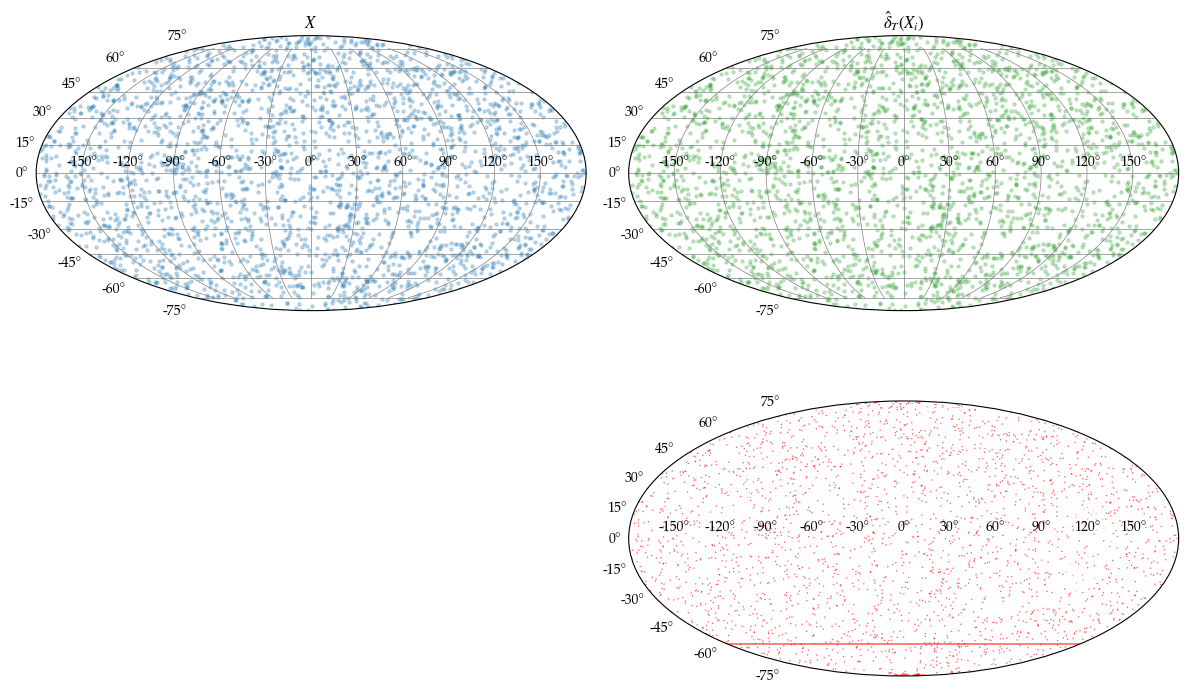

In [35]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8), subplot_kw={'projection': 'mollweide'})

# Top-left plot: X
axs[0, 0].grid(True, color='gray', lw=0.5)
axs[0, 0].set_title('$X$')
scatter_mollwide(X, ax=axs[0, 0], color='C0', alpha=0.25)

# Top-right plot: $\hat{\delta}_T(X_i)$
axs[0, 1].grid(True, color='gray', lw=0.5)
axs[0, 1].set_title('$\\hat{\\delta}_T(X_i)$')
scatter_mollwide(delta, ax=axs[0, 1], color='C2', alpha=0.25)

# Compute displacement vectors in spherical coordinates
# Convert to Mollweide coordinates for plotting
X_sph = sphere.extrinsic_to_spherical(X)
delta_sph = sphere.extrinsic_to_spherical(delta)
X_phi_mw = X_sph[:, 1] - np.pi
X_theta_mw = np.pi/2 - X_sph[:, 0]


delta_phi_mw = delta_sph[:, 1] - np.pi
delta_theta_mw = np.pi/2 - delta_sph[:, 0]

# Compute displacement
u = delta_phi_mw - X_phi_mw
v = delta_theta_mw - X_theta_mw

# Subsample for clearer visualization
stride = 1
axs[1,1].quiver(X_phi_mw[::stride], X_theta_mw[::stride], 
          u[::stride], v[::stride], 
          color='red', alpha=0.6, scale=5, width=0.003)

# Hide bottom-left and bottom-right axes
axs[1, 0].axis('off')

ax.grid(True, color='gray', lw=0.5)
ax.set_title('Denoiser displacement: $X_i \\rightarrow \\hat{\\delta}_T(X_i)$')
plt.tight_layout()
plt.show()